# HubbardEd Plot-Sammlung

In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from scipy.sparse.linalg import eigsh


directory = os.path.dirname(__file__) if "__file__" in globals() else os.getcwd()
sys.path.append(os.path.abspath(os.path.join(directory, "src")))

from hubbardEd.bitmapped import (
    bm_create_base_hamiltonian,
    bitmap_basis_states,
    bm_get_eigenstates,
    get_doublon_expectation,
    get_LRC_expectation,
    time_evolve_state,
    setup_hubbard_system,
)
from hubbardEd.analog import hamiltonian as analog_hamiltonian
from hubbardEd.analog import basis_states as analog_basis_states
from hubbardEd.cavity import site_correlation, create_cavity_hamiltonian, spinless_fermion_basis

## Eigenwertvergleich: Bitmapped vs. Analog

Vergleicht die Eigenwertspektren der bitmapped- und der analogen Darstellung für ein 2-Site-System im gleichen projizierten Teilraum.

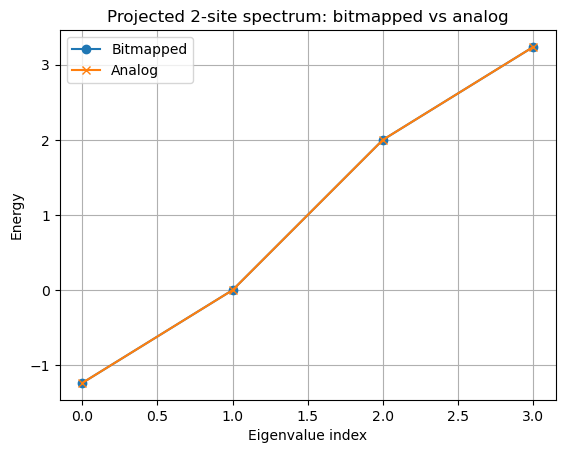

In [2]:
U = 2.0
t = 1.0

fig, ax = plt.subplots()

N_up, N_down, L = 1, 1, 2
_, index_map_analog = analog_basis_states(N_up + N_down, L)
bm_basis, index_map_bm = bitmap_basis_states(L, N_up, N_down)

HH_bm = bm_create_base_hamiltonian(bm_basis, index_map_bm, L, t, U).toarray()
HH_analog = analog_hamiltonian(N_up + N_down, L, t, U).toarray()

target_states_analog = [(1, 2), (2, 1), (3, 0), (0, 3)]
indices_analog = [index_map_analog[state] for state in target_states_analog]
HH_analog = HH_analog[np.ix_(indices_analog, indices_analog)]

target_states_bm = [(0b10, 0b01), (0b01, 0b10), (0b10, 0b10), (0b01, 0b01)]
indices_bm = [index_map_bm[state] for state in target_states_bm]
HH_bm = HH_bm[np.ix_(indices_bm, indices_bm)]

eigvals_bm = np.linalg.eigvalsh(HH_bm)
eigvals_analog = np.linalg.eigvalsh(HH_analog)

ax.plot(eigvals_bm, label="Bitmapped", marker="o")
ax.plot(eigvals_analog, label="Analog", marker="x")
ax.set_xlabel("Eigenvalue index")
ax.set_ylabel("Energy")
ax.set_title("Projected 2-site spectrum: bitmapped vs analog")
ax.grid()
ax.legend()

plt.show()

### Interpretation

Beide Kurven liegen übereinander, was bedeutet, dass beide Darstellungen konsistente Ergebnisse liefer. 

## Doublon-Erwartung pro Site mit Slider ueber U

Berechnet die standortaufgeloeste Doublon-Erwartung für viele U-Werte und visualisiert sie interaktiv mit einem Slider.

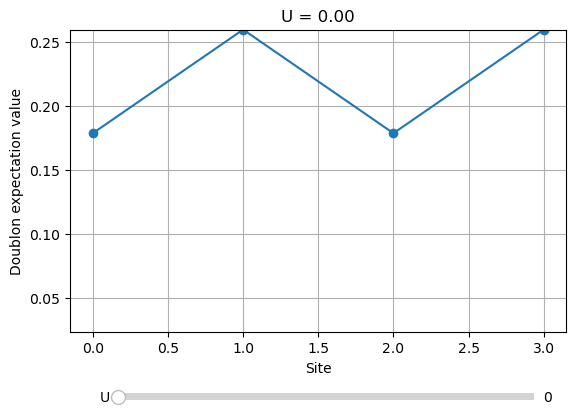

In [3]:
U_values = np.linspace(0, 10, 50)
doublon_expectations = []

N_up, N_down, L = 2, 2, 4
t = 1.0

bm_basis, index_map_bm = bitmap_basis_states(L, N_up, N_down)

# Precompute doublon expectations for all U values
for U in U_values:
    H = bm_create_base_hamiltonian(bm_basis, index_map_bm, L, t, U)
    _, eigvecs = bm_get_eigenstates(H, num_evals=3)
    ground_state = eigvecs[:, 0]
    doublon_exp = get_doublon_expectation(ground_state, bm_basis, L)
    doublon_expectations.append(doublon_exp)

doublon_expectations = np.array(doublon_expectations)

fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)

(l,) = ax.plot(range(L), doublon_expectations[0], marker="o")
ax.set_xlabel("Site")
ax.set_ylabel("Doublon expectation value")
ax.set_ylim(np.min(doublon_expectations), np.max(doublon_expectations))
ax.grid()

axcolor = "lightgoldenrodyellow"
axU = plt.axes((0.2, 0.1, 0.65, 0.03), facecolor=axcolor)
slider_U = Slider(axU, "U", U_values[0], U_values[-1], valinit=U_values[0], valstep=U_values)


def update(_value) -> None:
    idx = np.argmin(np.abs(U_values - slider_U.val))
    l.set_ydata(doublon_expectations[idx])
    ax.set_title(f"U = {U_values[idx]:.2f}")
    ax.set_ylim(np.min(doublon_expectations), np.max(doublon_expectations))
    fig.canvas.draw_idle()


slider_U.on_changed(update)
ax.set_title(f"U = {U_values[0]:.2f}")

plt.show()

### Interpretation

Der Slider zeigt, wie sich die räumliche Verteilung der Doublons mit der Wechselwirkung U verändert.
Mit wachsendem U wird Doppelbesetzung energetisch teurer, was sich in einer reduzierten oder umverteilten Doublon-Struktur zeigt.

## LRC-Erwartungswert als Funktion von U

Berechnet die Long-Range-Correlation (LRC) des Grundzustands fuer dieselbe Parameterfamilie U_values.

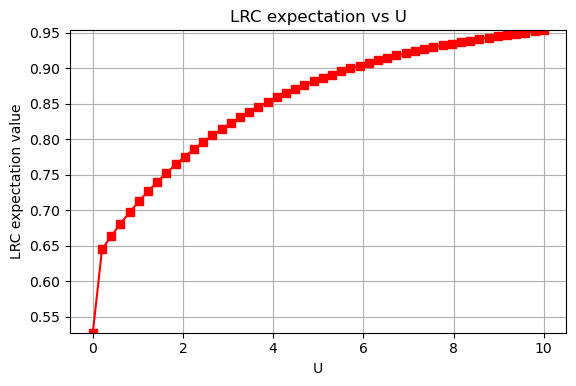

In [4]:
lrc_expectations = []

bm_basis, index_map_bm = bitmap_basis_states(L, N_up, N_down)

# Compute LRC expectation values for all U values
for U in U_values:
    H = bm_create_base_hamiltonian(bm_basis, index_map_bm, L, t, U)
    _, eigvecs = bm_get_eigenstates(H, num_evals=3)
    ground_state = eigvecs[:, 0]
    lrc_exp = get_LRC_expectation(ground_state, bm_basis, L)
    lrc_expectations.append(lrc_exp)

lrc_expectations = np.array(lrc_expectations)

fig2, ax2 = plt.subplots()
plt.subplots_adjust(bottom=0.25)

(l2,) = ax2.plot(U_values, lrc_expectations, marker="s", color="red")
ax2.set_xlabel("U")
ax2.set_ylabel("LRC expectation value")
ax2.set_ylim(np.min(lrc_expectations), np.max(lrc_expectations))
ax2.grid()
ax2.set_title("LRC expectation vs U")

plt.show()

### Interpretation

Die Kurve zeigt, wie sich die korrelation zwischen der ersten und mittleren Site des Rings mit steigender Site Interaction verändert. Die Annäherung an 1 ist zu erwarten, da für steigende U jede Site immer von einem Elektron besetzt wird, da die Doppelbesetzung energetisch immer teurer wird.

## Gauge-Vergleich: Velocity vs. Length

Vergleicht nach zeitabhaengiger Entwicklung den totalen Doublon-Erwartungswert als Funktion der Antriebsfrequenz omega fuer beide Gauges.

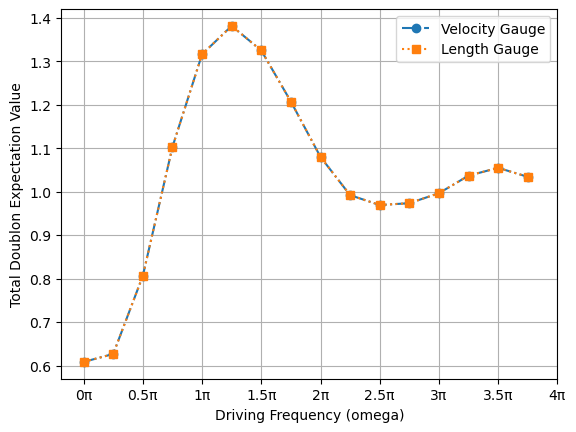

In [5]:
system = setup_hubbard_system(
    N_up=2, N_down=2, L=4, t=1.0, U=2.0, PBC=False, e_charge=1, hbar_val=1
)
HH_0 = system["H_int"] + system["H_hop"] + system["H_hop"].T.conj()
eigvals, eigvecs = bm_get_eigenstates(HH_0, num_evals=3)
psi_0 = eigvecs[:, 0]


vel_exp = []
len_exp = []

omegas = np.arange(0, 4 * np.pi, np.pi / 4)

for omega in omegas:

    vel_field = lambda t: (1 - np.cos(omega * t))
    length_field = lambda t: (-omega * np.sin(omega * t))

    psi_velocity = time_evolve_state(
        psi_0,
        system,
        gauge_choice="velocity",
        gauge_field=vel_field,
        t0=0,
        tf=1,
        num_points=800,
    )
    psi_length = time_evolve_state(
        psi_0,
        system,
        gauge_choice="length",
        gauge_field=length_field,
        t0=0,
        tf=1,
        num_points=800,
    )

    doublon_vel_exp = get_doublon_expectation(
        psi_velocity, system["basis"], system["Params"]["L"]
    )
    doublon_len_exp = get_doublon_expectation(
        psi_length, system["basis"], system["Params"]["L"]
    )

    tot_doublon_exp_vel = np.sum(doublon_vel_exp)
    tot_doublon_exp_len = np.sum(doublon_len_exp)

    vel_exp.append(tot_doublon_exp_vel)
    len_exp.append(tot_doublon_exp_len)


fig, ax = plt.subplots()

ax.plot(
    omegas,
    vel_exp,
    label="Velocity Gauge",
    marker="o",
    linestyle="-.",
)
ax.plot(
    omegas,
    len_exp,
    label="Length Gauge",
    marker="s",
    linestyle=":",
)

ax.set_xlabel("Driving Frequency (omega)")
ax.set_ylabel("Total Doublon Expectation Value")

omega_ticks = np.arange(0, 4 * np.pi + np.pi / 2, np.pi / 2)

ax.set_xticks(omega_ticks)
ax.set_xticklabels([f"{x/np.pi:.2g}π" for x in omega_ticks])

ax.legend()
ax.grid()

plt.show()

### Interpretation

Beide Kurven liegen aufeinander, was bedeutet, dass beide gauges dieselben physikalischen Ergebnisse liefern trotz der unterschiedlichen Ansätze. 

## Totaler Doublon-Erwartungswert gegen U

Berechnet den totalen Doublon-Erwartungswert im Grundzustand als Funktion der Wechselwirkungsstaerke U.

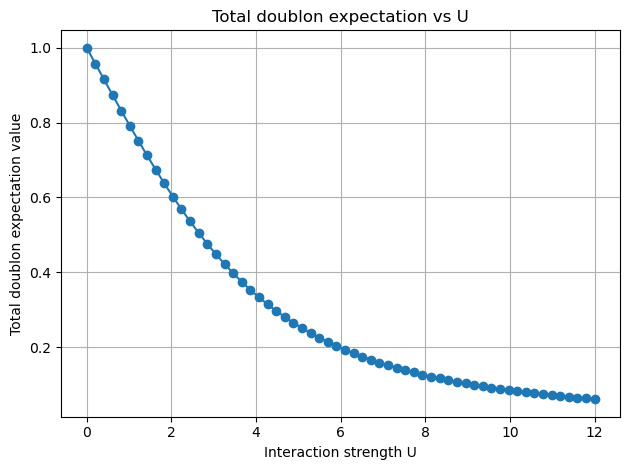

In [6]:
# Total doublon expectation value vs interaction strength U
N_up, N_down, L = 2, 2, 4
t_hop = 1.0
U_values = np.linspace(0.0, 12.0, 60)

total_doublon_vs_U = []

for U in U_values:
    system = setup_hubbard_system(
        N_up=N_up,
        N_down=N_down,
        L=L,
        t=t_hop,
        U=U,
        PBC=False,
        e_charge=1,
        hbar_val=1,
    )

    H0 = system["H_int"] + system["H_hop"] + system["H_hop"].T.conj()
    _, eigvecs = bm_get_eigenstates(H0, num_evals=1)
    ground_state = eigvecs[:, 0]

    doublon_site_resolved = get_doublon_expectation(ground_state, system["basis"], L)
    total_doublon_vs_U.append(np.sum(doublon_site_resolved))

plt.figure()
plt.plot(U_values, total_doublon_vs_U, marker="o", linestyle="-")
plt.xlabel("Interaction strength U")
plt.ylabel("Total doublon expectation value")
plt.title("Total doublon expectation vs U")
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation

Die Gesamtzahl an doublonen in der Kette nimmt mit steigender Wechselwirkungsstaerke U ab, da Doppelbesetzung energetisch immer teurer wird.

## Differenz der LRC zwischen unterschiedlichen Kopplungsstärkung g gegen U

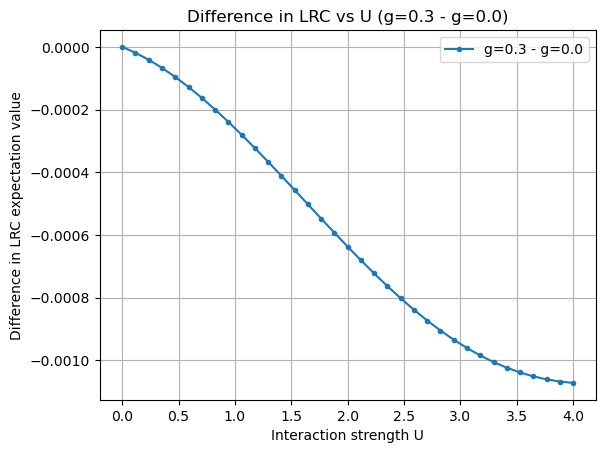

In [7]:
system_params = {"N_ferm": 3, "L": 6, "N_ph": 16, "pbc": True}
energy_params = {"t": 1.0, "U_min": 0.0, "U_max": 4.0, "U_point": 35, "omega_c": 1.0}

fermion_basis, index_map = spinless_fermion_basis(system_params["L"], system_params["N_ferm"])
g_values = (0.0, 0.3)


def get_lrc(hamiltonian) -> float:
    ground_state = eigsh(hamiltonian, k=1, which="SA")[1][:, 0]
    lrc_value = site_correlation(
        ground_state, 0, system_params["L"] // 2, index_map, system_params["N_ph"]
    )
    return lrc_value


U_vals = np.linspace(energy_params["U_min"], energy_params["U_max"], energy_params["U_point"])
lrc_diff = []
for U in U_vals:
    H_cavity_1 = create_cavity_hamiltonian(
        fermion_basis,
        index_map,
        system_params["L"],
        energy_params["t"],
        U,
        system_params["N_ph"],
        g_values[0],
        energy_params["omega_c"],
        system_params["pbc"],
    )
    H_cavity_2 = create_cavity_hamiltonian(
        fermion_basis,
        index_map,
        system_params["L"],
        energy_params["t"],
        U,
        system_params["N_ph"],
        g_values[1],
        energy_params["omega_c"],
        system_params["pbc"],
    )

    lrc_1 = get_lrc(H_cavity_1)
    lrc_2 = get_lrc(H_cavity_2)

    lrc_diff.append(lrc_2 - lrc_1)

fig, ax = plt.subplots()

ax.set_xlabel("Interaction strength U")
ax.set_ylabel("Difference in LRC expectation value")
ax.set_title("Difference in LRC vs U (g=0.3 - g=0.0)")

ax.plot(U_vals, lrc_diff, marker=".", linestyle="-", label="g=0.3 - g=0.0")
ax.grid()
ax.legend()

plt.show()

### Interpretation

The cavity coupling changes the LRC only weakly in this parameter set, but the difference is systematic and becomes more negative as U increases. That indicates a small cavity-induced suppression of long-range charge alignment.

In [10]:
p_sys = {
    "L": 10, # number of lattice sites
    "N_ferm": 5,
    "N_ph": 16, # maximum number of photons in the cavity mode
    "pbc": True, # periodic boundary conditions
    "t": 1.0, # hopping amplitude
    "U": 2.0, # interaction strength
    "omega": 1.0, # cavity frequency
}
site_indices = np.arange(p_sys["L"])

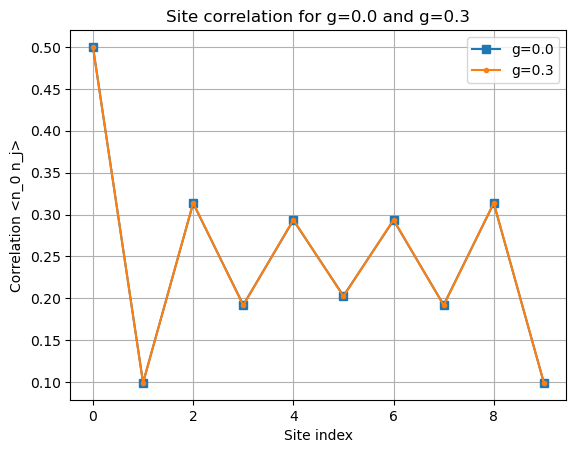

In [11]:
fermion_basis, index_map = spinless_fermion_basis(p_sys['L'], p_sys['N_ferm'])

g = (0.0, 0.3)
H_cavity_1 = create_cavity_hamiltonian(fermion_basis, index_map, p_sys['L'], p_sys['t'], p_sys['U'], p_sys['N_ph'], g[0], p_sys['omega'], pbc=p_sys['pbc'])
H_cavity_2 = create_cavity_hamiltonian(fermion_basis, index_map, p_sys['L'], p_sys['t'], p_sys['U'], p_sys['N_ph'], g[1], p_sys['omega'], pbc=p_sys['pbc'])

ground_state_1 = eigsh(H_cavity_1, k=1, which='SA')[1][:, 0]
ground_state_2 = eigsh(H_cavity_2, k=1, which='SA')[1][:, 0]

corr_g1 = []
corr_g2 = []
for site in site_indices:
    corr_g1.append(site_correlation(ground_state_1, 0, site, index_map, p_sys['N_ph']))
    corr_g2.append(site_correlation(ground_state_2, 0, site, index_map, p_sys['N_ph']))
    
fig, ax = plt.subplots()

ax.set_xlabel("Site index")
ax.set_ylabel("Correlation <n_0 n_j>")
ax.set_title("Site correlation for g=0.0 and g=0.3")

ax.plot(site_indices, corr_g1, label="g=0.0", marker="s")
ax.plot(site_indices, corr_g2, label="g=0.3", marker=".")
ax.legend()
ax.grid()

plt.show()

### Interpretation

The two curves almost completely overlap, so the cavity coupling g = 0.3 has only a very small effect on the site-resolved correlation pattern at this filling and system size.

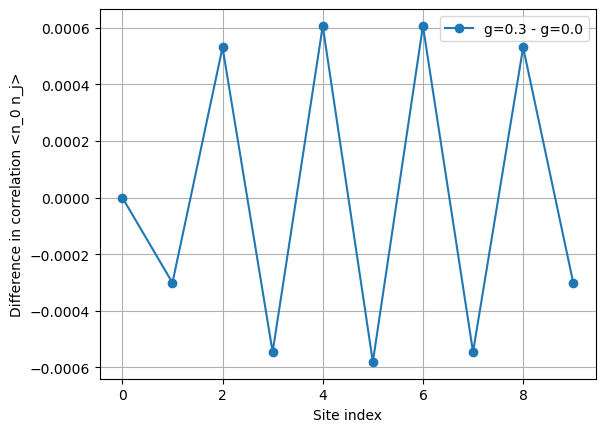

In [12]:
difference_corr = np.array(corr_g2) - np.array(corr_g1)

fig, ax = plt.subplots()

ax.set_xlabel("Site index")
ax.set_ylabel("Difference in correlation <n_0 n_j>")

ax.plot(site_indices, difference_corr, label="g=0.3 - g=0.0", marker="o")
ax.legend()
ax.grid()
plt.show()

### Interpretation

The difference oscillates around zero with a small amplitude, which means the cavity coupling perturbs the correlation profile in a site-dependent way rather than shifting it uniformly.